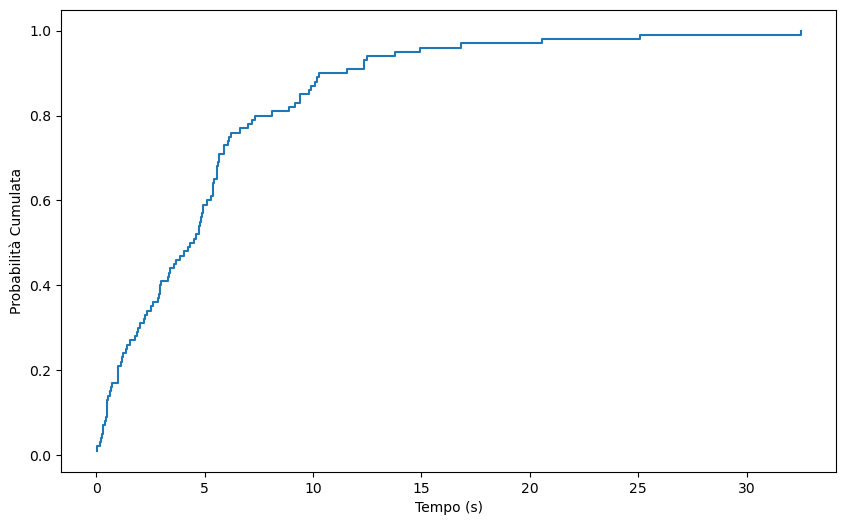

In [7]:
#test di KS

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

#userò solo i primi 100 valori del file
n = 100

#uso uno dei file
dati = np.loadtxt("../Esercitazione_4/dati/conteggi_geiger_amb.txt", max_rows=n)

dati = dati*1e-3

#Calcolo le frequenze cumulative empiriche 

# Ordino i dati dal più piccolo al più grande
dati_ordinati = np.sort(dati)

# Le funzione delle frequenze cumulative è definita come:
# F_n(x_i) = i / n
#
# dove:
# - i è la posizione del dato ordinato
# - n è il numero totale di dati

# quindi il mio y sara' dato semplicemente da  
y_fc = np.arange(1, n + 1) / n
#mentre come x usero' i dati ordinati

plt.figure(figsize=(10, 6))
plt.step(dati_ordinati, y_fc, label='Frequenza cumulativa empirica', where='post')
plt.xlabel("Tempo (s)")
plt.ylabel("Probabilità Cumulata")
plt.show()

In [8]:
#ora aggiungo il calcolo della cumulativa teorica

# F(t) = 1 - exp(-t / tau)
def cdf_esponenziale(t, tau):
    return 1 - np.exp(-t / tau)

tau_hat = np.mean(dati)
print(f"tau_teorico {tau_hat:.2f}")
y_teorica = cdf_esponenziale(dati_ordinati, tau_hat)

#Uso le librerie di scipy per calcolare la distanza massima e il corrispondente p-value
D, pvalue = kstest(dati, cdf_esponenziale, args=(tau_hat,)) #la virgola dopo tau_hat serve a indicare che è una tupla di un solo elemento
print(f"D: {D}, p-value ottimistico: {pvalue}")

tau_teorico 5.21
D: 0.07983184583924685, p-value ottimistico: 0.5209129493014297


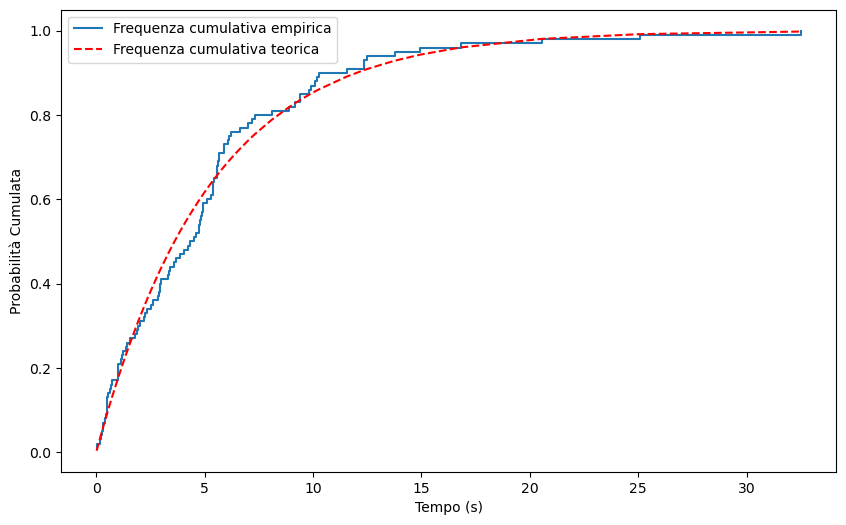

In [9]:
#sovrappongo la curva teorica a quella empirica
plt.figure(figsize=(10, 6))
plt.step(dati_ordinati, y_fc, label='Frequenza cumulativa empirica', where='post')
plt.plot(dati_ordinati, y_teorica, 'r--', label='Frequenza cumulativa teorica')
plt.xlabel("Tempo (s)")
plt.ylabel("Probabilità Cumulata")
plt.legend()
plt.show()

In [10]:
# ------------------------------------------------------------
# Toy Monte Carlo
# ------------------------------------------------------------

Ntoys = 10000

D_toys = np.zeros(Ntoys)

for i in range(Ntoys):

    # genero un fake dataset sotto H0
    u = np.random.uniform(0,1,n)
    e = - tau_hat * np.log(1-u)

    # ristimo tau sul fake dataset
    tau_fake = np.mean(e)

    # ricalcolo KS usando il tau del singolo toy model
    D_fake, _ = kstest(e, cdf_esponenziale, args=(tau_fake,))

    D_toys[i] = D_fake

In [11]:
#Calcolo il valore critico di D dalla distribuzione dei D_toys

D_crit_5 = np.quantile(D_toys, 0.95)

print(f"\nValore critico KS al 5% = {D_crit_5:.5f}")

# decisione del test
if D > D_crit_5:
    print("\nRigetto H0 al 5%")
else:
    print("\nNON rigetto H0 al 5%")




Valore critico KS al 5% = 0.10744

NON rigetto H0 al 5%


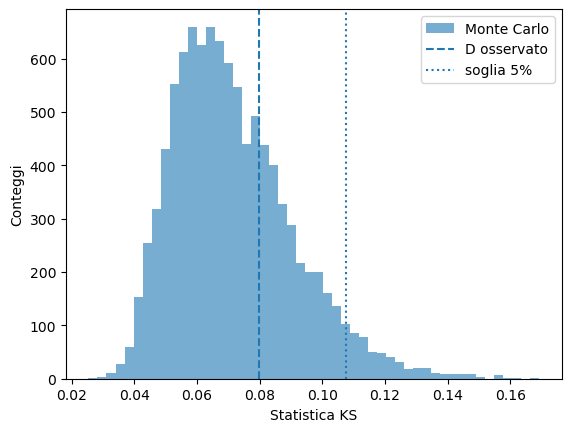

In [12]:
# ------------------------------------------------------------
# Grafico distribuzione nulla della statistica KS
# ------------------------------------------------------------

plt.hist(D_toys, bins=50, alpha=0.6, label="Monte Carlo")

plt.axvline(D, linestyle='--', label='D osservato')
plt.axvline(D_crit_5, linestyle=':', label='soglia 5%')

plt.xlabel("Statistica KS")
plt.ylabel("Conteggi")

plt.legend()

plt.show()